# Importing Libraries

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif

# Importing The Dataset

In [2]:
cancer = pd.read_csv('breast_cancer.csv')
cancer

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
cancer = cancer.iloc[:, 1:32]
cancer

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
cancer['diagnosis'].replace("M","0",inplace=True)
cancer['diagnosis'].replace("B","1",inplace=True)
cancer['diagnosis'] = cancer['diagnosis'].astype(str).astype(int)
cancer

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,0,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,0,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,0,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
cancer.keys()

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [6]:
print("Malignant : ",(cancer.diagnosis.values == 0).sum())
print("Benign : ",(cancer.diagnosis.values == 1).sum())

Malignant :  212
Benign :  357


In [7]:
cancer.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [8]:
x = cancer.drop(['diagnosis'], axis = 1)
y = cancer['diagnosis']
mutual_info = mutual_info_classif(x,y)
mutual_info = pd.Series(mutual_info)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

perimeter_worst            0.474976
area_worst                 0.465071
radius_worst               0.455484
concave points_mean        0.440047
concave points_worst       0.435338
perimeter_mean             0.404459
concavity_mean             0.372725
radius_mean                0.367060
area_mean                  0.361449
area_se                    0.339364
concavity_worst            0.315402
perimeter_se               0.277460
radius_se                  0.249979
compactness_worst          0.225756
compactness_mean           0.212875
concave points_se          0.127808
texture_worst              0.120277
concavity_se               0.117545
smoothness_worst           0.104168
texture_mean               0.096881
symmetry_worst             0.088529
smoothness_mean            0.079635
compactness_se             0.072837
symmetry_mean              0.065083
fractal_dimension_worst    0.064459
fractal_dimension_se       0.037712
symmetry_se                0.015899
smoothness_se              0

In [9]:
cancer.mean()

diagnosis                    0.627417
radius_mean                 14.127292
texture_mean                19.289649
perimeter_mean              91.969033
area_mean                  654.889104
smoothness_mean              0.096360
compactness_mean             0.104341
concavity_mean               0.088799
concave points_mean          0.048919
symmetry_mean                0.181162
fractal_dimension_mean       0.062798
radius_se                    0.405172
texture_se                   1.216853
perimeter_se                 2.866059
area_se                     40.337079
smoothness_se                0.007041
compactness_se               0.025478
concavity_se                 0.031894
concave points_se            0.011796
symmetry_se                  0.020542
fractal_dimension_se         0.003795
radius_worst                16.269190
texture_worst               25.677223
perimeter_worst            107.261213
area_worst                 880.583128
smoothness_worst             0.132369
compactness_

In [10]:
cancer.min()

diagnosis                    0.000000
radius_mean                  6.981000
texture_mean                 9.710000
perimeter_mean              43.790000
area_mean                  143.500000
smoothness_mean              0.052630
compactness_mean             0.019380
concavity_mean               0.000000
concave points_mean          0.000000
symmetry_mean                0.106000
fractal_dimension_mean       0.049960
radius_se                    0.111500
texture_se                   0.360200
perimeter_se                 0.757000
area_se                      6.802000
smoothness_se                0.001713
compactness_se               0.002252
concavity_se                 0.000000
concave points_se            0.000000
symmetry_se                  0.007882
fractal_dimension_se         0.000895
radius_worst                 7.930000
texture_worst               12.020000
perimeter_worst             50.410000
area_worst                 185.200000
smoothness_worst             0.071170
compactness_

In [11]:
cancer.max()

diagnosis                     1.00000
radius_mean                  28.11000
texture_mean                 39.28000
perimeter_mean              188.50000
area_mean                  2501.00000
smoothness_mean               0.16340
compactness_mean              0.34540
concavity_mean                0.42680
concave points_mean           0.20120
symmetry_mean                 0.30400
fractal_dimension_mean        0.09744
radius_se                     2.87300
texture_se                    4.88500
perimeter_se                 21.98000
area_se                     542.20000
smoothness_se                 0.03113
compactness_se                0.13540
concavity_se                  0.39600
concave points_se             0.05279
symmetry_se                   0.07895
fractal_dimension_se          0.02984
radius_worst                 36.04000
texture_worst                49.54000
perimeter_worst             251.20000
area_worst                 4254.00000
smoothness_worst              0.22260
compactness_

In [12]:
cancer.std()

diagnosis                    0.483918
radius_mean                  3.524049
texture_mean                 4.301036
perimeter_mean              24.298981
area_mean                  351.914129
smoothness_mean              0.014064
compactness_mean             0.052813
concavity_mean               0.079720
concave points_mean          0.038803
symmetry_mean                0.027414
fractal_dimension_mean       0.007060
radius_se                    0.277313
texture_se                   0.551648
perimeter_se                 2.021855
area_se                     45.491006
smoothness_se                0.003003
compactness_se               0.017908
concavity_se                 0.030186
concave points_se            0.006170
symmetry_se                  0.008266
fractal_dimension_se         0.002646
radius_worst                 4.833242
texture_worst                6.146258
perimeter_worst             33.602542
area_worst                 569.356993
smoothness_worst             0.022832
compactness_

# Visualizing The Data

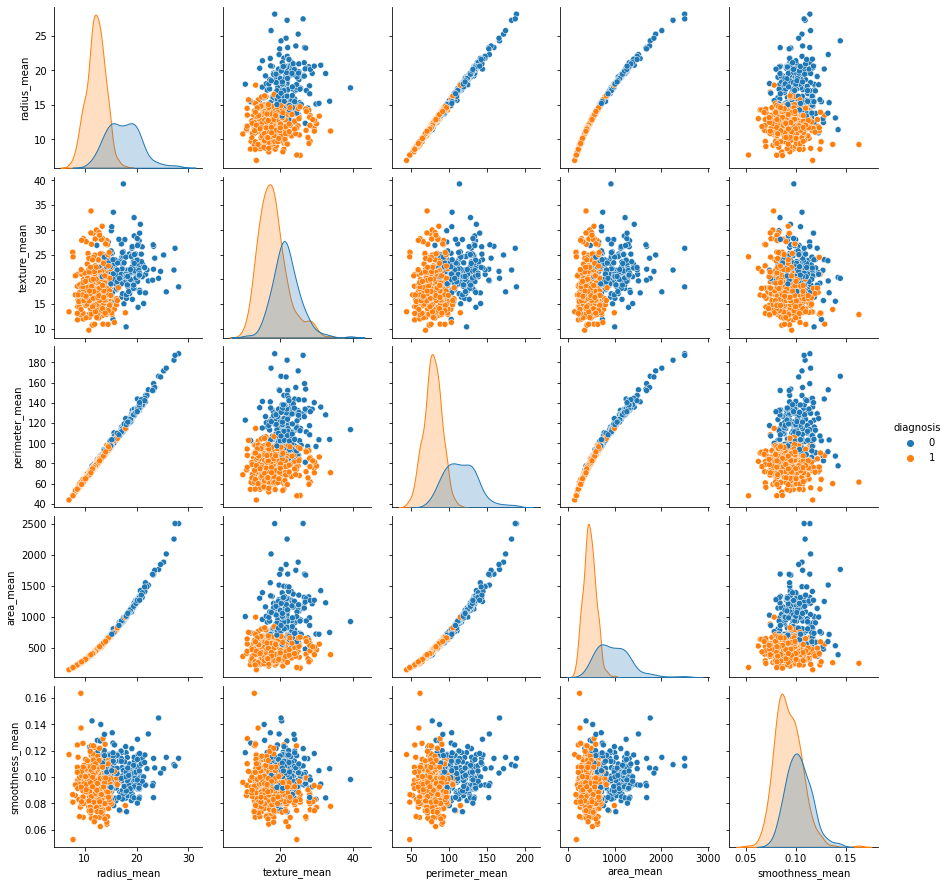

In [13]:
sns.pairplot(cancer, hue = 'diagnosis', vars = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean'])

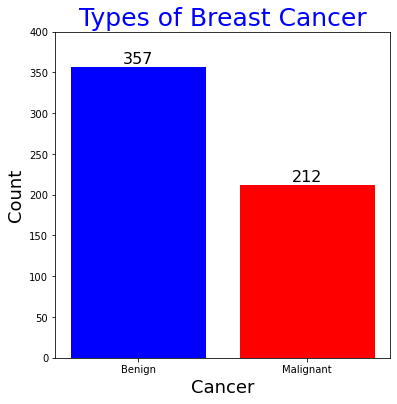

In [14]:
plt.figure(figsize=(6,6))
names = ["Benign", "Malignant"]
count = [(cancer.diagnosis.values == 1).sum(), (cancer.diagnosis.values == 0).sum()]
plt.bar(names, count, color = ["Blue", "Red"])
plt.title('Types of Breast Cancer', color = 'blue', fontsize= 25)
plt.xlabel('Cancer', fontsize= 18)
plt.ylabel('Count', fontsize= 18)
plt.ylim(0,400)
for i in range(len(names)):
    plt.text(i, count[i], count[i], ha='center', va='bottom', fontsize=16)
plt.show()

<AxesSubplot:xlabel='area_mean', ylabel='smoothness_mean'>

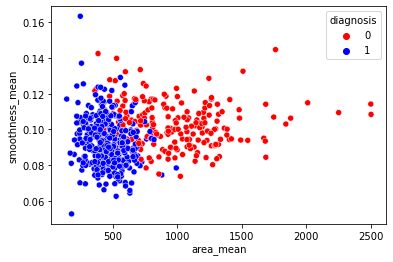

In [15]:
sns.scatterplot(x = 'area_mean', y = 'smoothness_mean', hue  = 'diagnosis', data = cancer, palette=['red','blue'])

<AxesSubplot:>

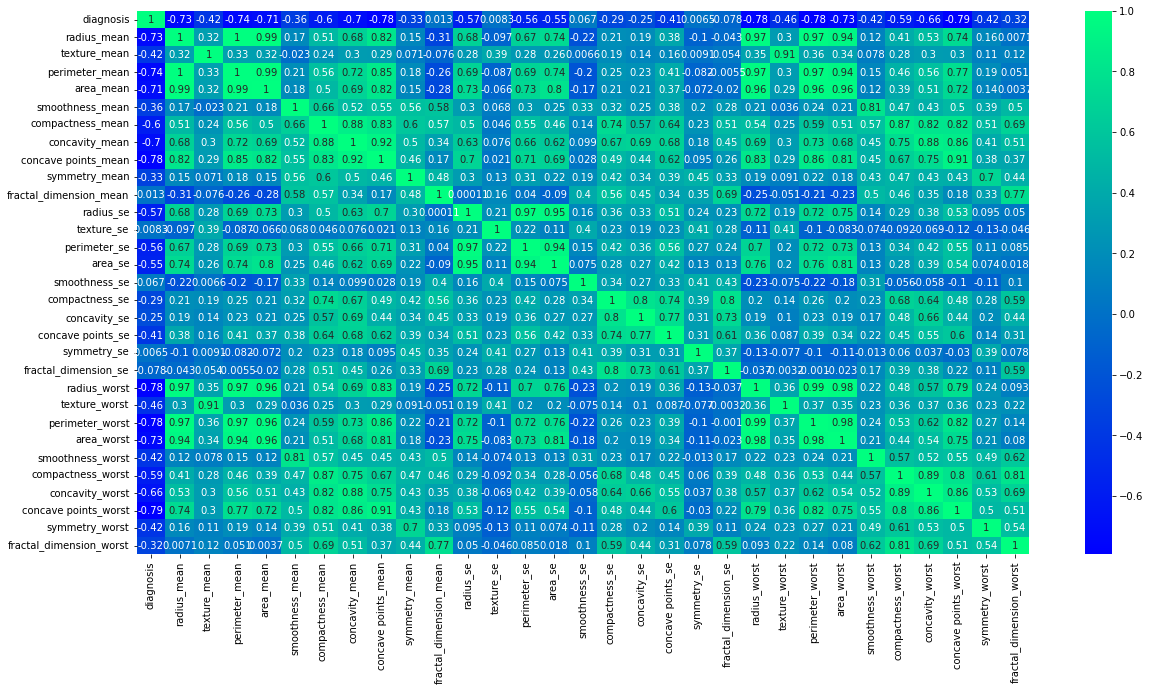

In [16]:
plt.figure(figsize = (20, 10))
sns.heatmap(cancer.corr(), annot = True, cmap="winter")

# Models Training

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.25)

# Support Vector Machine (SVM)
svm = SVC().fit(x_train, y_train)

# Random Forest (RF)
RF = RandomForestClassifier().fit(x_train, y_train)

#K-nearest neighbors (KNN)
KNN = KNeighborsClassifier().fit(x_train, y_train)

# Decision Tree (DT)
DT = DecisionTreeClassifier().fit(x_train, y_train)

# Naive Bayes (NB)
NB = GaussianNB().fit(x_train, y_train)

# Logistic Regression (LR)
LR = LogisticRegression(solver='liblinear',max_iter=3000).fit(x_train, y_train)

# AdaBoostClassifier (AB)
AB = AdaBoostClassifier().fit(x_train, y_train)

# GradientBoostingClassifier (GB)
GB = GradientBoostingClassifier().fit(x_train, y_train)

# Multi-layer perceptron (MLP)
MLP = MLPClassifier().fit(x_train, y_train)

# Nearest Centroid Classifier (NCC)
NCC = NearestCentroid().fit(x_train, y_train)

# Voting Classifier (VC)
est = [('svm',svm), ('lr',LR)]
VC = VotingClassifier(estimators = est, voting ='hard').fit(x_train, y_train)

# Evaluating Models

In [18]:
# Support Vector Machine (SVM)
svm_pre = svm.predict(x_test)
svm_sc = svm.score(x_test, y_test) * 100
svm_sc = "{:.2f}".format(svm_sc)

# Random Forest (RF)
rf_pre = RF.predict(x_test)
RF_sc = RF.score(x_test, y_test) * 100
RF_sc = "{:.2f}".format(RF_sc)

#K-nearest neighbors (KNN)
knn_pre = KNN.predict(x_test)
KNN_sc = KNN.score(x_test, y_test) * 100
KNN_sc = "{:.2f}".format(KNN_sc)

# Decision Tree (DT)
dt_pre = DT.predict(x_test)
DT_sc = DT.score(x_test, y_test) * 100
DT_sc = "{:.2f}".format(DT_sc)

# Naive Bayes (NB)
nb_pre = NB.predict(x_test)
NB_sc = NB.score(x_test, y_test) * 100
NB_sc = "{:.2f}".format(NB_sc)

# Logistic Regression (LR)
lr_pre = LR.predict(x_test)
LR_sc = LR.score(x_test, y_test) * 100
LR_sc = "{:.2f}".format(LR_sc)

# AdaBoostClassifier (AB)
ab_pre = AB.predict(x_test)
AB_sc = AB.score(x_test, y_test) * 100
AB_sc = "{:.2f}".format(AB_sc)

# GradientBoostingClassifier (GB)
gb_pre = GB.predict(x_test)
GB_sc = GB.score(x_test, y_test) * 100
GB_sc = "{:.2f}".format(GB_sc)

# Multi-layer perceptron (MLP)
mlp_pre = MLP.predict(x_test)
MLP_sc = MLP.score(x_test, y_test) * 100
MLP_sc = "{:.2f}".format(MLP_sc)

# Nearest Centroid Classifier (NCC)
ncc_pre = NCC.predict(x_test)
NCC_sc = NCC.score(x_test, y_test) * 100
NCC_sc = "{:.2f}".format(NCC_sc)

# Voting Classifier (VC)
vc_pre = VC.predict(x_test)
vc_sc = VC.score(x_test, y_test) * 100
vc_sc = "{:.2f}".format(vc_sc)

# Accuracy (Before Optimization)

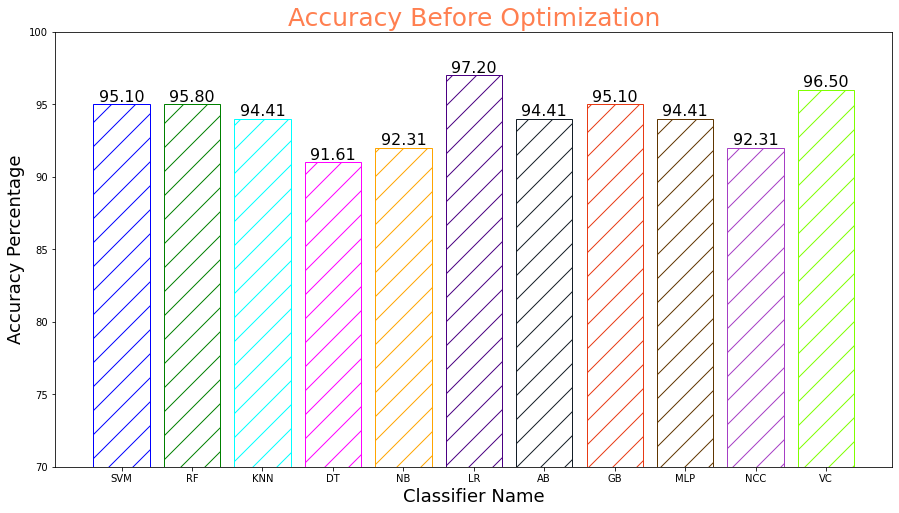

In [19]:
plt.figure(figsize=(15,8))
algo = ['SVM', 'RF', 'KNN', 'DT', 'NB', 'LR', 'AB', 'GB', 'MLP', 'NCC', 'VC']
acc = [math.floor(int(float(svm_sc))),math.floor(int(float(RF_sc))),math.floor(int(float(KNN_sc))),math.floor(int(float(DT_sc))),math.floor(int(float(NB_sc))),math.floor(int(float(LR_sc))),math.floor(int(float(AB_sc))),math.floor(int(float(GB_sc))),math.floor(int(float(MLP_sc))),math.floor(int(float(NCC_sc))),math.floor(int(float(vc_sc)))]
pert = [svm_sc, RF_sc, KNN_sc, DT_sc, NB_sc, LR_sc, AB_sc, GB_sc, MLP_sc, NCC_sc, vc_sc]
colors = ['blue', 'green', 'cyan', 'magenta', 'orange', 'Indigo', '#141E27', '#E83A14', '#603601', '#A63EC5', 'chartreuse']
plt.bar(algo, acc,color='white', edgecolor=colors, hatch='/')
plt.title('Accuracy Before Optimization', color = 'coral', fontsize= 25)
plt.xlabel('Classifier Name', fontsize= 18)
plt.ylabel('Accuracy Percentage', fontsize= 18)
plt.ylim(70,100)
for i in range(len(algo)):
    plt.text(i, acc[i], pert[i], ha='center', va='bottom', fontsize=16)
plt.show()

In [20]:
pd.DataFrame(classification_report(y_test, svm_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.975610,0.941176,0.951049,0.958393,0.952253
recall,0.869565,0.989691,0.951049,0.929628,0.951049
f1-score,0.919540,0.964824,0.951049,0.942182,0.950257
support,46.000000,97.000000,0.951049,143.000000,143.000000


In [21]:
pd.DataFrame(classification_report(y_test, rf_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.916667,0.978947,0.958042,0.947807,0.958913
recall,0.956522,0.958763,0.958042,0.957642,0.958042
f1-score,0.936170,0.968750,0.958042,0.952460,0.958270
support,46.000000,97.000000,0.958042,143.000000,143.000000


In [22]:
pd.DataFrame(classification_report(y_test, knn_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.913043,0.958763,0.944056,0.935903,0.944056
recall,0.913043,0.958763,0.944056,0.935903,0.944056
f1-score,0.913043,0.958763,0.944056,0.935903,0.944056
support,46.000000,97.000000,0.944056,143.000000,143.000000


In [23]:
pd.DataFrame(classification_report(y_test, dt_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.840000,0.956989,0.916084,0.898495,0.919356
recall,0.913043,0.917526,0.916084,0.915285,0.916084
f1-score,0.875000,0.936842,0.916084,0.905921,0.916949
support,46.000000,97.000000,0.916084,143.000000,143.000000


In [24]:
pd.DataFrame(classification_report(y_test, nb_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.843137,0.967391,0.923077,0.905264,0.927421
recall,0.934783,0.917526,0.923077,0.926154,0.923077
f1-score,0.886598,0.941799,0.923077,0.914198,0.924042
support,46.000000,97.000000,0.923077,143.000000,143.000000


In [25]:
pd.DataFrame(classification_report(y_test, lr_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.937500,0.989474,0.972028,0.963487,0.972755
recall,0.978261,0.969072,0.972028,0.973667,0.972028
f1-score,0.957447,0.979167,0.972028,0.968307,0.972180
support,46.000000,97.000000,0.972028,143.000000,143.000000


In [26]:
pd.DataFrame(classification_report(y_test, ab_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.895833,0.968421,0.944056,0.932127,0.945071
recall,0.934783,0.948454,0.944056,0.941618,0.944056
f1-score,0.914894,0.958333,0.944056,0.936613,0.944360
support,46.000000,97.000000,0.944056,143.000000,143.000000


In [27]:
pd.DataFrame(classification_report(y_test, gb_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.897959,0.978723,0.951049,0.938341,0.952743
recall,0.956522,0.948454,0.951049,0.952488,0.951049
f1-score,0.926316,0.963351,0.951049,0.944833,0.951437
support,46.000000,97.000000,0.951049,143.000000,143.000000


In [28]:
pd.DataFrame(classification_report(y_test, mlp_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.880000,0.978495,0.944056,0.929247,0.946811
recall,0.956522,0.938144,0.944056,0.947333,0.944056
f1-score,0.916667,0.957895,0.944056,0.937281,0.944633
support,46.000000,97.000000,0.944056,143.000000,143.000000


In [29]:
pd.DataFrame(classification_report(y_test, ncc_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,1.000000,0.898148,0.923077,0.949074,0.930912
recall,0.760870,1.000000,0.923077,0.880435,0.923077
f1-score,0.864198,0.946341,0.923077,0.905269,0.919918
support,46.000000,97.000000,0.923077,143.000000,143.000000


In [30]:
pd.DataFrame(classification_report(y_test, vc_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.918367,0.989362,0.965035,0.953865,0.966524
recall,0.978261,0.958763,0.965035,0.968512,0.965035
f1-score,0.947368,0.973822,0.965035,0.960595,0.965312
support,46.000000,97.000000,0.965035,143.000000,143.000000


# Features Scaling

In [31]:
scaler = StandardScaler()
scaler.fit(x)
scaled_x = scaler.transform(x)

# Using PCA with Cross Validation

In [32]:
pca = PCA(n_components=16)
pca.fit(scaled_x)
pca_x = pca.transform(scaled_x)
pca_x.shape

(569, 16)

# Hyper parameter Tuning (GridSearchCV)

In [33]:
#Support Vector Machine (SVM)
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}
 
grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3)
grid.fit(pca_x, y)
grid.best_params_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.623 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.623 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.632 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.632 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.628 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.930 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.895 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.965 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.965 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.912 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

In [34]:
#K-nearest neighbors (KNN)
k_range = list(range(1,31))
weight_options = ["uniform", "distance"]

param_grid = dict(n_neighbors = k_range, weights = weight_options)
#print (param_grid)
knn = KNeighborsClassifier()

grid = GridSearchCV(knn, param_grid, cv = 10, scoring = 'accuracy')
grid.fit(pca_x,y)
grid.best_params_

{'n_neighbors': 7, 'weights': 'uniform'}

In [35]:
# Decision Tree (DT)
param_grid = {
              'max_depth': [2, 3, 5, 10, 20],
                'min_samples_leaf': [5, 10, 20, 50, 100],
              'criterion' :['gini', 'entropy']
             }
dt = DecisionTreeClassifier()

grid = GridSearchCV(dt, param_grid, cv = 10, scoring = 'accuracy')
grid.fit(pca_x,y)
grid.best_params_

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5}

# Evaluating Models

In [36]:
#Support Vector Machine (SVM)
svm = SVC(C= 10, gamma= 0.01, kernel= 'rbf')
svm_y_pre = cross_val_predict(svm, pca_x, y, cv=9)
svm_sc = accuracy_score(y, svm_y_pre) * 100
svm_sc = "{:.2f}".format(svm_sc)

# Random Forest (RF)
RF = RandomForestClassifier()
rf_y_pre = cross_val_predict(RF, pca_x, y, cv=10)
RF_sc = accuracy_score(y, rf_y_pre) * 100
RF_sc = "{:.2f}".format(RF_sc)

#K-nearest neighbors (KNN)
KNN = KNeighborsClassifier(n_neighbors= 7, weights= 'uniform')
knn_y_pre = cross_val_predict(KNN, pca_x, y, cv=10)
KNN_sc = accuracy_score(y, knn_y_pre) * 100
KNN_sc = "{:.2f}".format(KNN_sc)

# Decision Tree (DT)
DT = DecisionTreeClassifier(criterion= 'gini', max_depth= 10, min_samples_leaf= 5)
dt_y_pre = cross_val_predict(DT, pca_x, y, cv=10)
DT_sc = accuracy_score(y, dt_y_pre) * 100
DT_sc = "{:.2f}".format(DT_sc)

# Naive Bayes (NB)
NB = GaussianNB()
nb_y_pre = cross_val_predict(NB, pca_x, y, cv=10)
NB_sc = accuracy_score(y, nb_y_pre) * 100
NB_sc = "{:.2f}".format(NB_sc)

# Logistic Regression (LR)
LR = LogisticRegression(max_iter=3000,C= 1.0, penalty= 'l2', solver= 'liblinear')
lr_y_pre = cross_val_predict(LR, pca_x, y, cv=9)
LR_sc = accuracy_score(y, lr_y_pre) * 100
LR_sc = "{:.2f}".format(LR_sc)

# AdaBoostClassifier (AB)
AB = AdaBoostClassifier()
ab_y_pre = cross_val_predict(AB, pca_x, y, cv=10)
AB_sc = accuracy_score(y, ab_y_pre) * 100
AB_sc = "{:.2f}".format(AB_sc)

# GradientBoostingClassifier (GB)
GB = GradientBoostingClassifier()
gb_y_pre = cross_val_predict(GB, pca_x, y, cv=10)
GB_sc = accuracy_score(y, gb_y_pre) * 100
GB_sc = "{:.2f}".format(GB_sc)

# Multi-layer perceptron (MLP)
MLP = MLPClassifier(max_iter=3000)
mlp_y_pre = cross_val_predict(MLP, pca_x, y, cv=9)
MLP_sc = accuracy_score(y, mlp_y_pre) * 100
MLP_sc = "{:.2f}".format(MLP_sc)

# Nearest Centroid Classifier (NCC)
NCC = NearestCentroid()
ncc_y_pre = cross_val_predict(NCC, pca_x, y, cv=10)
NCC_sc = accuracy_score(y, ncc_y_pre) * 100
NCC_sc = "{:.2f}".format(NCC_sc)

# Voting Classifier (VC)
est = [('svm',svm), ('lr',LR)]
vot_hard = VotingClassifier(estimators = est, voting ='hard')
vc_y_pre = cross_val_predict(vot_hard, pca_x, y, cv=10)
vc_sc = accuracy_score(y, vc_y_pre) * 100
vc_sc = "{:.2f}".format(vc_sc)

# Accuracy (After Optimization) With Cross Validation

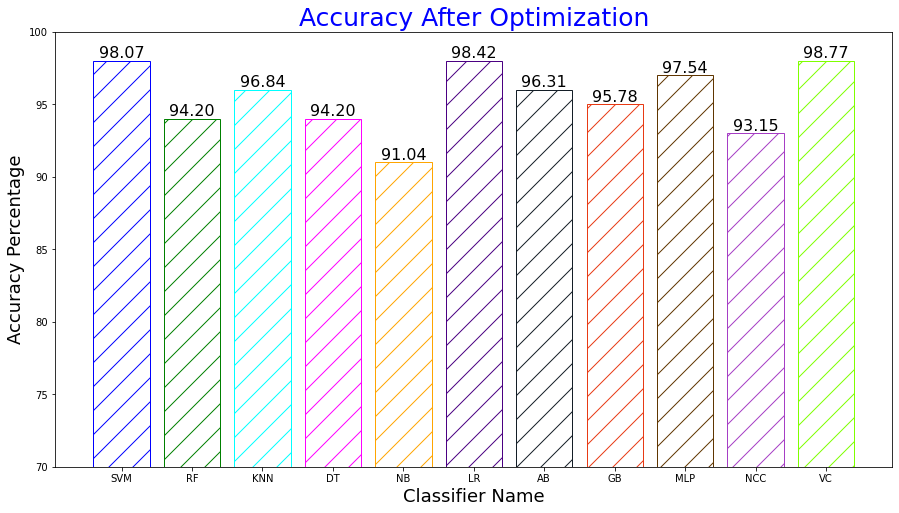

In [37]:
plt.figure(figsize=(15,8))
algo = ['SVM', 'RF', 'KNN', 'DT', 'NB', 'LR', 'AB', 'GB', 'MLP', 'NCC', 'VC']
acc = [math.floor(int(float(svm_sc))),math.floor(int(float(RF_sc))),math.floor(int(float(KNN_sc))),math.floor(int(float(DT_sc))),math.floor(int(float(NB_sc))),math.floor(int(float(LR_sc))),math.floor(int(float(AB_sc))),math.floor(int(float(GB_sc))),math.floor(int(float(MLP_sc))),math.floor(int(float(NCC_sc))),math.floor(int(float(vc_sc)))]
pert = [svm_sc, RF_sc, KNN_sc, DT_sc, NB_sc, LR_sc, AB_sc, GB_sc, MLP_sc, NCC_sc, vc_sc]
colors = ['blue', 'green', 'cyan', 'magenta', 'orange', 'Indigo', '#141E27', '#E83A14', '#603601', '#A63EC5', 'chartreuse']
plt.bar(algo, acc,color='white', edgecolor=colors, hatch='/')
plt.title('Accuracy After Optimization', color = 'blue', fontsize= 25)
plt.xlabel('Classifier Name', fontsize= 18)
plt.ylabel('Accuracy Percentage', fontsize= 18)
plt.ylim(70,100)
for i in range(len(algo)):
    plt.text(i, acc[i], pert[i], ha='center', va='bottom', fontsize=16)
plt.show()

# Classification Report and Confusion Matrix

In [38]:
def print_confusion_matrix(confusion_matrix, class_names, figsize = (7,4), fontsize=14, title = "Confusion Matrix"):
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names, 
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d", cmap='winter')
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=90, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=0, ha='center', fontsize=fontsize)
    plt.ylabel('Truth', fontsize=18, color='blue')
    plt.xlabel('Prediction',  fontsize=18, color='blue')
    plt.title(title, fontsize=22, color='blue')

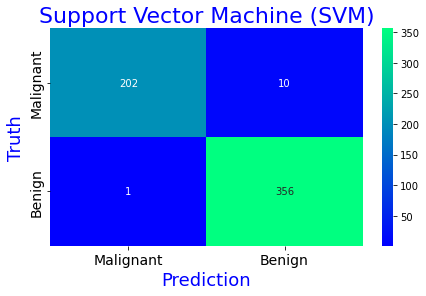

In [39]:
cm = confusion_matrix(y, svm_y_pre)
print_confusion_matrix(cm,["Malignant", "Benign"], title="Support Vector Machine (SVM)")

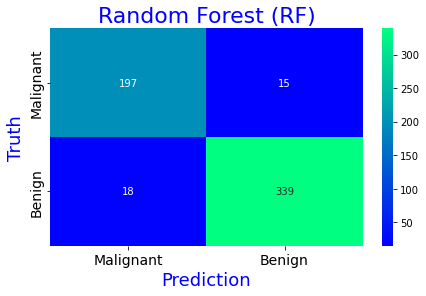

In [40]:
cm = confusion_matrix(y, rf_y_pre)
print_confusion_matrix(cm,["Malignant", "Benign"], title="Random Forest (RF)")

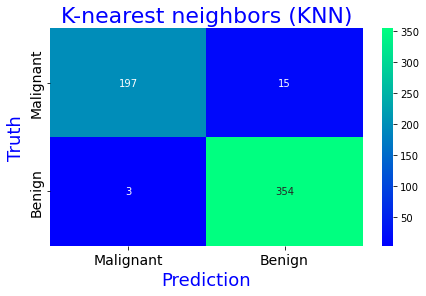

In [41]:
cm = confusion_matrix(y, knn_y_pre)
print_confusion_matrix(cm,["Malignant", "Benign"], title="K-nearest neighbors (KNN)")

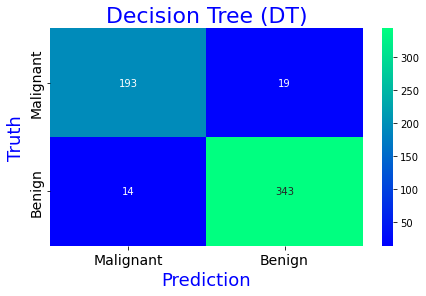

In [42]:
cm = confusion_matrix(y, dt_y_pre)
print_confusion_matrix(cm,["Malignant", "Benign"], title="Decision Tree (DT)")

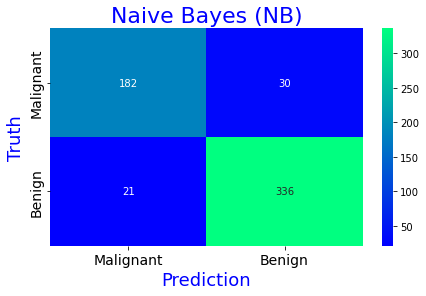

In [43]:
cm = confusion_matrix(y, nb_y_pre)
print_confusion_matrix(cm,["Malignant", "Benign"], title="Naive Bayes (NB)")

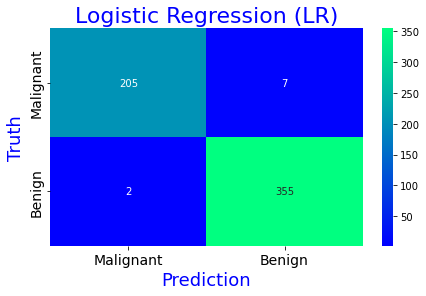

In [44]:
cm = confusion_matrix(y, lr_y_pre)
print_confusion_matrix(cm,["Malignant", "Benign"], title="Logistic Regression (LR)")

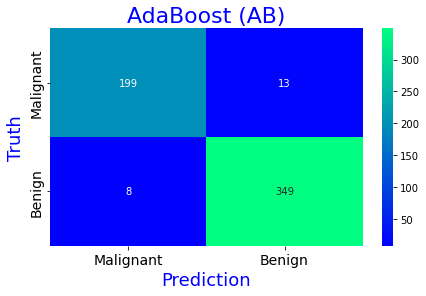

In [45]:
cm = confusion_matrix(y, ab_y_pre)
print_confusion_matrix(cm,["Malignant", "Benign"], title="AdaBoost (AB)")

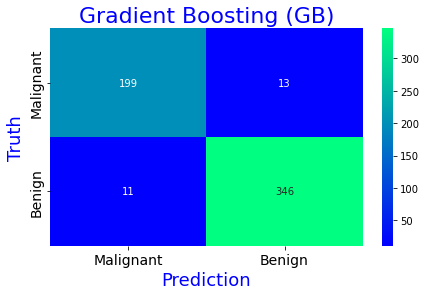

In [46]:
cm = confusion_matrix(y, gb_y_pre)
print_confusion_matrix(cm,["Malignant", "Benign"], title="Gradient Boosting (GB)")

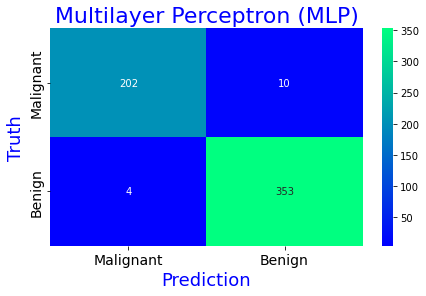

In [47]:
cm = confusion_matrix(y, mlp_y_pre)
print_confusion_matrix(cm,["Malignant", "Benign"], title="Multilayer Perceptron (MLP)")

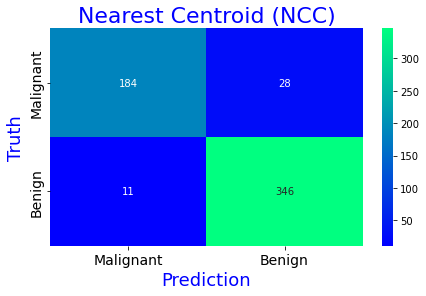

In [48]:
cm = confusion_matrix(y, ncc_y_pre)
print_confusion_matrix(cm,["Malignant", "Benign"], title="Nearest Centroid (NCC)")

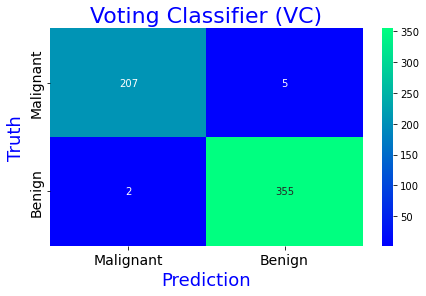

In [49]:
cm = confusion_matrix(y, vc_y_pre)
print_confusion_matrix(cm,["Malignant", "Benign"], title="Voting Classifier (VC)")

In [50]:
pd.DataFrame(classification_report(y, svm_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.995074,0.972678,0.980668,0.983876,0.981022
recall,0.952830,0.997199,0.980668,0.975015,0.980668
f1-score,0.973494,0.984786,0.980668,0.979140,0.980579
support,212.000000,357.000000,0.980668,569.000000,569.000000


In [51]:
pd.DataFrame(classification_report(y, rf_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.916279,0.957627,0.942004,0.936953,0.942222
recall,0.929245,0.949580,0.942004,0.939413,0.942004
f1-score,0.922717,0.953586,0.942004,0.938152,0.942085
support,212.000000,357.000000,0.942004,569.000000,569.000000


In [52]:
pd.DataFrame(classification_report(y, knn_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.985000,0.959350,0.968366,0.972175,0.968907
recall,0.929245,0.991597,0.968366,0.960421,0.968366
f1-score,0.956311,0.975207,0.968366,0.965759,0.968166
support,212.000000,357.000000,0.968366,569.000000,569.000000


In [53]:
pd.DataFrame(classification_report(y, dt_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.932367,0.947514,0.942004,0.939940,0.941870
recall,0.910377,0.960784,0.942004,0.935581,0.942004
f1-score,0.921241,0.954103,0.942004,0.937672,0.941859
support,212.000000,357.000000,0.942004,569.000000,569.000000


In [54]:
pd.DataFrame(classification_report(y, nb_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.896552,0.918033,0.910369,0.907292,0.910029
recall,0.858491,0.941176,0.910369,0.899834,0.910369
f1-score,0.877108,0.929461,0.910369,0.903285,0.909955
support,212.000000,357.000000,0.910369,569.000000,569.000000


In [55]:
pd.DataFrame(classification_report(y, lr_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.990338,0.980663,0.984183,0.985501,0.984268
recall,0.966981,0.994398,0.984183,0.980689,0.984183
f1-score,0.978520,0.987483,0.984183,0.983001,0.984143
support,212.000000,357.000000,0.984183,569.000000,569.000000


In [56]:
pd.DataFrame(classification_report(y, ab_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.961353,0.964088,0.963093,0.962721,0.963069
recall,0.938679,0.977591,0.963093,0.958135,0.963093
f1-score,0.949881,0.970793,0.963093,0.960337,0.963001
support,212.000000,357.000000,0.963093,569.000000,569.000000


In [57]:
pd.DataFrame(classification_report(y, gb_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.947619,0.963788,0.957821,0.955704,0.957764
recall,0.938679,0.969188,0.957821,0.953933,0.957821
f1-score,0.943128,0.966480,0.957821,0.954804,0.957780
support,212.000000,357.000000,0.957821,569.000000,569.000000


In [58]:
pd.DataFrame(classification_report(y, mlp_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.980583,0.972452,0.975395,0.976517,0.975481
recall,0.952830,0.988796,0.975395,0.970813,0.975395
f1-score,0.966507,0.980556,0.975395,0.973531,0.975321
support,212.000000,357.000000,0.975395,569.000000,569.000000


In [59]:
pd.DataFrame(classification_report(y, ncc_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.943590,0.925134,0.931459,0.934362,0.932010
recall,0.867925,0.969188,0.931459,0.918556,0.931459
f1-score,0.904177,0.946648,0.931459,0.925413,0.930824
support,212.000000,357.000000,0.931459,569.000000,569.000000


In [60]:
pd.DataFrame(classification_report(y, vc_y_pre, output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.990431,0.986111,0.987698,0.988271,0.987720
recall,0.976415,0.994398,0.987698,0.985406,0.987698
f1-score,0.983373,0.990237,0.987698,0.986805,0.987680
support,212.000000,357.000000,0.987698,569.000000,569.000000


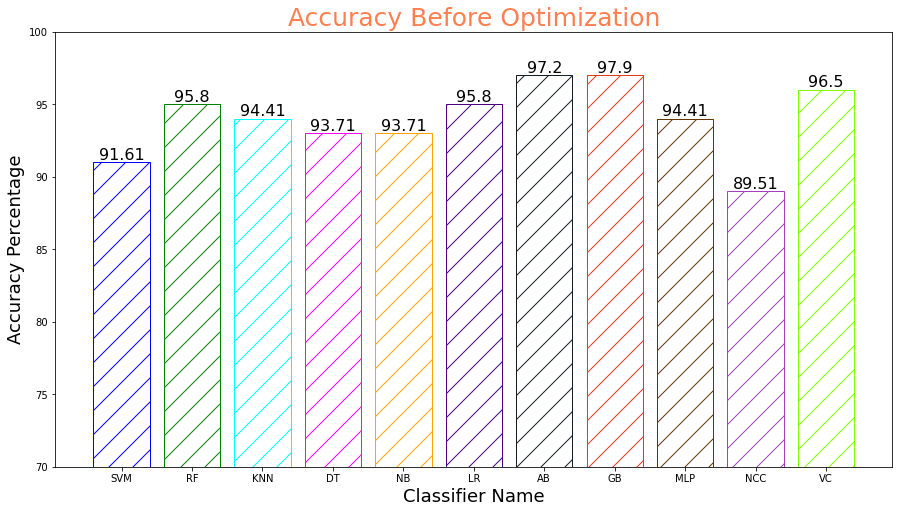

In [61]:
plt.figure(figsize=(15,8))
algo = ['SVM', 'RF', 'KNN', 'DT', 'NB', 'LR', 'AB', 'GB', 'MLP', 'NCC', 'VC']
acc = [math.floor(int(float('91.61'))),math.floor(int(float('95.80'))),math.floor(int(float('94.41'))),math.floor(int(float('93.71'))),math.floor(int(float('93.71'))),math.floor(int(float('95.80'))),math.floor(int(float('97.20'))),math.floor(int(float('97.90'))),math.floor(int(float('94.41'))),math.floor(int(float('89.51'))),math.floor(int(float('96.50')))]
pert = [91.61, 95.80, 94.41, 93.71, 93.71, 95.80, 97.20, 97.90, 94.41, 89.51, 96.50]
colors = ['blue', 'green', 'cyan', 'magenta', 'orange', 'Indigo', '#141E27', '#E83A14', '#603601', '#A63EC5', 'chartreuse']
plt.bar(algo, acc,color='white', edgecolor=colors, hatch='/')
plt.title('Accuracy Before Optimization', color = 'coral', fontsize= 25)
plt.xlabel('Classifier Name', fontsize= 18)
plt.ylabel('Accuracy Percentage', fontsize= 18)
plt.ylim(70,100)
for i in range(len(algo)):
    plt.text(i, acc[i], pert[i], ha='center', va='bottom', fontsize=16)
plt.show()